# VAE Celeba Images

In [1]:
%reload_ext watermark
%watermark -a 'Yasir Awais Butt' -v -p torch

Author: Yasir Awais Butt

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.13.0

torch: 2.11.0+cu128



## Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import celeba
from torchvision import datasets

In [3]:
RANDOM_SEED = 42
NUM_EPOCHS = 5
BATCH_SIZE = 256
LEARNING_RATE = 0.0005

In [4]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {DEVICE}")
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


Using device: cuda


## Dataset

In [5]:
transform = transforms.Compose([
    transforms.CenterCrop((128, 128)),
    transforms.ToTensor()]
)

In [6]:
train_dataset = datasets.CelebA(root = "data", 
                              split = "train", 
                              download = True,
                              transform = transform)
test_dataset = datasets.CelebA(root = "data", 
                              split = "test", 
                              download = True,
                              transform = transform)


In [7]:
train_dataloader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False)

In [8]:
print('Training Dataset')
for images, labels in train_dataloader:
    print(f"Image batch dimensions: {images.shape}")
    print(f"Label batch dimensions: {labels.shape}")
    break

Training Dataset
Image batch dimensions: torch.Size([256, 3, 128, 128])
Label batch dimensions: torch.Size([256, 40])


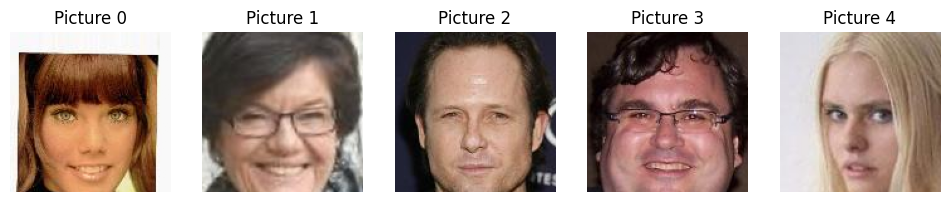

In [9]:
plt.figure(figsize=(12, 3))
for i in range(5):
    images, labels = next(iter(train_dataloader))
    img = images[0]  # first image in the batch
    plt.subplot(1, 5, i + 1)
    
    plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title(f"Picture {i}")
plt.show()    

In [10]:
# Checking the dataset
print('\nTesting Set:')
for images, labels in test_dataloader:  
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    #print(labels[:10])
    break
    
"""Targets are 40-dim vectors representing
00 - 5_o_Clock_Shadow
01 - Arched_Eyebrows
02 - Attractive 
03 - Bags_Under_Eyes
04 - Bald
05 - Bangs
06 - Big_Lips
07 - Big_Nose
08 - Black_Hair
09 - Blond_Hair
10 - Blurry 
11 - Brown_Hair 
12 - Bushy_Eyebrows 
13 - Chubby 
14 - Double_Chin 
15 - Eyeglasses 
16 - Goatee 
17 - Gray_Hair 
18 - Heavy_Makeup 
19 - High_Cheekbones 
20 - Male 
21 - Mouth_Slightly_Open 
22 - Mustache 
23 - Narrow_Eyes 
24 - No_Beard 
25 - Oval_Face 
26 - Pale_Skin 
27 - Pointy_Nose 
28 - Receding_Hairline 
29 - Rosy_Cheeks 
30 - Sideburns 
31 - Smiling 
32 - Straight_Hair 
33 - Wavy_Hair 
34 - Wearing_Earrings 
35 - Wearing_Hat 
36 - Wearing_Lipstick 
37 - Wearing_Necklace 
38 - Wearing_Necktie 
39 - Young         
"""


Testing Set:
Image batch dimensions: torch.Size([256, 3, 128, 128])
Image label dimensions: torch.Size([256, 40])


'Targets are 40-dim vectors representing\n00 - 5_o_Clock_Shadow\n01 - Arched_Eyebrows\n02 - Attractive \n03 - Bags_Under_Eyes\n04 - Bald\n05 - Bangs\n06 - Big_Lips\n07 - Big_Nose\n08 - Black_Hair\n09 - Blond_Hair\n10 - Blurry \n11 - Brown_Hair \n12 - Bushy_Eyebrows \n13 - Chubby \n14 - Double_Chin \n15 - Eyeglasses \n16 - Goatee \n17 - Gray_Hair \n18 - Heavy_Makeup \n19 - High_Cheekbones \n20 - Male \n21 - Mouth_Slightly_Open \n22 - Mustache \n23 - Narrow_Eyes \n24 - No_Beard \n25 - Oval_Face \n26 - Pale_Skin \n27 - Pointy_Nose \n28 - Receding_Hairline \n29 - Rosy_Cheeks \n30 - Sideburns \n31 - Smiling \n32 - Straight_Hair \n33 - Wavy_Hair \n34 - Wearing_Earrings \n35 - Wearing_Hat \n36 - Wearing_Lipstick \n37 - Wearing_Necklace \n38 - Wearing_Necktie \n39 - Young         \n'

## Model

In [11]:
class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)
class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()
        

    def forward(self, x):
        return x[:, :, :128, :128]
    
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias = False),  # (32, 64, 64)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias = False), # (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias = False), # (128, 16, 16)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias = False), # (256, 8, 8)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Flatten(), # (64*8*8,)
        )
        self.z_mean = nn.Linear(4096, 200)
        self.z_log_var = nn.Linear(4096, 200)

        self.decoder = nn.Sequential(
            nn.Linear(200, 4096),
            Reshape(-1, 64, 8, 8), # (256, 8, 8)
            #
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, bias = False), # (128, 14, 14)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, bias = False), # (64, 28, 28)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, bias = False), # (32, 56, 56)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.ConvTranspose2d(32, 3, kernel_size=3,stride=2,padding=1, bias = False), # (3 ,112 ,112)
            Trim(),
            nn.Sigmoid() 
        )
    def encoding_fn(self, x):
        h = self.encoder(x)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)
        return self.reparameterize(z_mean, z_log_var)
    def reparameterize(self, z_mu, z_log_var):
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(z_mu.get_device())
        z = z_mu + eps * torch.exp(z_log_var/2.) 
        return z
    
    def forward(self,x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded, z_mean, z_log_var, decoded

In [12]:
model = VAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [13]:
from util_train import train_vae_v1

In [14]:
log_dict = train_vae_v1(num_epochs=NUM_EPOCHS, model=model, 
                        optimizer=optimizer, device=DEVICE, 
                        train_loader=train_dataloader,
                        skip_epoch_stats=True,
                        logging_interval=50,
                        save_model='vae_celeba_02.pt')

/mnt/D/test/deep-learning-Raschka/L17/util_train.py:78: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Epoch: %03d/%03d | Batch %04d/%04d | Loss: %.4f'


Epoch: 001/005 | Batch 0000/0636 | Loss: 5247.6191
Epoch: 001/005 | Batch 0050/0636 | Loss: 2042.0718
Epoch: 001/005 | Batch 0100/0636 | Loss: 1485.6721
Epoch: 001/005 | Batch 0150/0636 | Loss: 1309.0680
Epoch: 001/005 | Batch 0200/0636 | Loss: 1180.2742
Epoch: 001/005 | Batch 0250/0636 | Loss: 1127.5967
Epoch: 001/005 | Batch 0300/0636 | Loss: 1055.4078
Epoch: 001/005 | Batch 0350/0636 | Loss: 1005.6967
Epoch: 001/005 | Batch 0400/0636 | Loss: 960.6678
Epoch: 001/005 | Batch 0450/0636 | Loss: 905.0377
Epoch: 001/005 | Batch 0500/0636 | Loss: 895.2955
Epoch: 001/005 | Batch 0550/0636 | Loss: 880.0881
Epoch: 001/005 | Batch 0600/0636 | Loss: 835.8080
Time elapsed: 19.83 min
Epoch: 002/005 | Batch 0000/0636 | Loss: 871.9922
Epoch: 002/005 | Batch 0050/0636 | Loss: 875.7599
Epoch: 002/005 | Batch 0100/0636 | Loss: 814.8580
Epoch: 002/005 | Batch 0150/0636 | Loss: 815.9226
Epoch: 002/005 | Batch 0200/0636 | Loss: 835.6390
Epoch: 002/005 | Batch 0250/0636 | Loss: 785.5414
Epoch: 002/005 | B

In [ ]:
def plot_training_loss(losses, num_epochs, custom_label=""):
    losses = np.array(losses)
    iters = np.arange(len(losses))
    plt.plot(iters, losses, label=f"Training{custom_label}")
    # estimate batches per epoch and draw separators
    if num_epochs > 1 and len(losses) >= num_epochs:
        batches_per_epoch = int(np.ceil(len(losses) / num_epochs))
        for e in range(1, num_epochs):
            plt.axvline(x=e * batches_per_epoch, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.legend()

ImportError: cannot import name 'plot_training_loss' from 'util_train' (/mnt/D/test/deep-learning-Raschka/L17/util_train.py)

In [ ]:
plot_training_loss(log_dict['train_reconstruction_loss_per_batch'], NUM_EPOCHS, custom_label=" (reconstruction)")
plot_training_loss(log_dict['train_kl_loss_per_batch'], NUM_EPOCHS, custom_label=" (KL)")
plot_training_loss(log_dict['train_combined_loss_per_batch'], NUM_EPOCHS, custom_label=" (combined)")
plt.show()